# Prédiction de notes d'hôtels — Sentence Transformers + Classification

**Approche :** On utilise le modèle pré-entraîné `all-MiniLM-L6-v2` pour transformer chaque commentaire
en un vecteur dense de 384 dimensions capturant le **sens global** de la phrase.
Ces vecteurs sont ensuite passés à un classifieur Logistic Regression.

**Différence clé avec TF-IDF :**
- TF-IDF → compte les mots, ignore le contexte
- Sentence Transformers → comprend le sens, le contexte, la sémantique

**Pipeline :**
1. Chargement des données
2. Préparation minimale du texte (pas de nettoyage agressif)
3. Génération des embeddings avec `all-MiniLM-L6-v2`
4. Entraînement — Logistic Regression
5. Évaluation et analyse des résultats
6. Comparaison avec la baseline TF-IDF

## 0. Installation des dépendances

À exécuter une seule fois si `sentence-transformers` n'est pas installé.

In [1]:
# Décommenter si nécessaire
# !pip install sentence-transformers scikit-learn pandas matplotlib

## 1. Imports

- `SentenceTransformer` : charge et utilise le modèle pré-entraîné
- `LogisticRegression` : classifieur entraîné sur les embeddings
- Pas besoin de `nltk` ici — aucun nettoyage manuel du texte

In [ ]:

# ─── Manipulation des données ────────────────────────────────────────────────
import pandas as pd          # Chargement et manipulation des CSV
import numpy as np           # Calculs matriciels, sauvegarde des embeddings (.npy)
import matplotlib.pyplot as plt  # Visualisations
import warnings
warnings.filterwarnings('ignore')

# ─── Sentence Transformers ───────────────────────────────────────────────────
from sentence_transformers import SentenceTransformer
# SentenceTransformer charge un modèle pré-entraîné et encode des textes en vecteurs denses.
# Contrairement à BERT brut (un vecteur par token), Sentence Transformers produit
# UN SEUL vecteur par phrase, optimisé pour capturer le sens global.
# Le modèle utilisé ici : all-MiniLM-L6-v2
#   → 384 dimensions (dense, toutes non nulles — opposé à TF-IDF qui est creux)
#   → ~80 Mo, rapide sur CPU
#   → Entraîné sur 1 milliard de paires de phrases par apprentissage contrastif
#     (deux phrases similaires → vecteurs proches, deux phrases opposées → vecteurs éloignés)

# ─── Classifieur ─────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
# On réutilise le même classifieur que TF-IDF.
# Seule la représentation du texte change : vecteur TF-IDF (creux, 20000 dim)
# est remplacé par un embedding dense (384 dim) — plus compact et sémantiquement riche.

# ─── Métriques ───────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,          # % de notes exactement correctes
    f1_score,                # Moyenne harmonique précision/rappel — robuste au déséquilibre
    classification_report,   # Détail par classe
    confusion_matrix,        # Matrice note réelle × note prédite
    ConfusionMatrixDisplay   # Affichage graphique
)

print('Imports OK')


## 2. Chargement des données

Même structure que pour TF-IDF : train / valid / test.
Les chemins sont relatifs au dossier `Sentence Transformers/`.

In [3]:
train_df = pd.read_csv('../train_hotel_reviews.csv')
valid_df = pd.read_csv('../valid_hotel_reviews.csv')
test_df  = pd.read_csv('../test_hotel_reviews.csv')

print(f'Train : {len(train_df)} exemples')
print(f'Valid : {len(valid_df)} exemples')
print(f'Test  : {len(test_df)} exemples')

train_df.head(3)

Train : 18491 exemples
Valid : 1000 exemples
Test  : 1000 exemples


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3


## 3. Préparation du texte

Contrairement à TF-IDF, on **ne fait pas** de nettoyage agressif ici.
Le modèle Sentence Transformers gère lui-même la tokenisation et comprend
la ponctuation, les majuscules et les stopwords ("not", "very" sont importants pour le sens).

On se contente de :
- Convertir les valeurs NaN en chaîne vide
- Supprimer les espaces superflus en début/fin

In [ ]:

def prepare_text(text):
    """
    Préparation minimale du texte pour Sentence Transformers.

    Pourquoi ne PAS nettoyer agressivement ici (contrairement à TF-IDF) ?

    Le modèle all-MiniLM-L6-v2 a été pré-entraîné sur du texte brut.
    Il a appris que :
    - "not good" ≠ "good" (la négation change le sens → conserver "not")
    - "Very clean room!" ≠ "clean room" (l'intensité compte → conserver "Very" et "!")
    - La ponctuation et les majuscules portent de l'information contextuelle

    Supprimer les stopwords ou la ponctuation DÉGRADERAIT les embeddings.
    On se contente du strict minimum : gérer les NaN et les espaces superflus.
    """
    # Convertir NaN en chaîne vide (sécurité si valeur manquante dans le CSV)
    # + supprimer les espaces en début/fin
    return str(text).strip()

# Appliquer la préparation minimale
train_texts = train_df['Review'].apply(prepare_text).tolist()
valid_texts = valid_df['Review'].apply(prepare_text).tolist()
test_texts  = test_df['Review'].apply(prepare_text).tolist()

# Labels : notes telles quelles (1 à 5) — pas de décalage nécessaire pour sklearn
# (contrairement à PyTorch où CrossEntropyLoss exige des labels 0 à 4)
y_train = train_df['Rating'].values
y_valid = valid_df['Rating'].values
y_test  = test_df['Rating'].values

# Vérification
print('Exemple de texte (brut, sans nettoyage) :')
print(train_texts[0][:300])
print(f'\nClasses : {sorted(set(y_train))}')


## 4. Génération des embeddings

C'est l'étape centrale. Le modèle `all-MiniLM-L6-v2` transforme chaque commentaire
en un vecteur dense de **384 dimensions**.

- `batch_size=64` : traite 64 commentaires à la fois (adapter selon la RAM)
- `show_progress_bar=True` : affiche la progression
- Le modèle est téléchargé automatiquement la première fois (~80 Mo)

> Sur CPU : environ 2–5 minutes pour 18 000 exemples.
> Les embeddings sont sauvegardés en `.npy` pour ne pas recalculer à chaque fois.

In [ ]:

import os

# ── Chargement du modèle pré-entraîné ────────────────────────────────────────
# all-MiniLM-L6-v2 : version allégée de MiniLM (6 couches, ~22M paramètres)
# Téléchargé automatiquement depuis HuggingFace Hub (~80 Mo) la première fois,
# puis mis en cache localement.
#
# Comparaison des modèles Sentence Transformers courants :
#   all-MiniLM-L6-v2    : 384 dim, ~80 Mo,  rapide, bon rapport perf/vitesse ← utilisé ici
#   all-MiniLM-L12-v2   : 384 dim, ~130 Mo, un peu plus précis
#   all-mpnet-base-v2   : 768 dim, ~420 Mo, plus précis mais 5x plus lent
#
# Pourquoi ce modèle et pas BERT directement ?
# BERT brut produit un vecteur par TOKEN (pas par phrase).
# Pour obtenir un vecteur de phrase avec BERT, il faudrait moyenner les tokens
# ou prendre le [CLS] — mais ces vecteurs ne sont pas optimisés pour la similarité.
# Sentence Transformers est spécifiquement ré-entraîné pour produire des vecteurs
# de phrase comparables et sémantiquement cohérents.
model = SentenceTransformer('all-MiniLM-L6-v2')
print(f'Modèle chargé. Dimension des embeddings : {model.get_sentence_embedding_dimension()}')


In [ ]:

# ── Calcul ou chargement des embeddings ──────────────────────────────────────
# Encoder 18 491 textes prend plusieurs minutes même sur CPU.
# On sauvegarde les résultats en .npy (format numpy binaire) pour ne pas
# recalculer à chaque fois qu'on relance le notebook.

CACHE_TRAIN = 'embeddings_train.npy'
CACHE_VALID = 'embeddings_valid.npy'
CACHE_TEST  = 'embeddings_test.npy'

if os.path.exists(CACHE_TRAIN):
    # Chargement depuis le cache — instantané
    print('Chargement des embeddings depuis le cache...')
    X_train = np.load(CACHE_TRAIN)
    X_valid = np.load(CACHE_VALID)
    X_test  = np.load(CACHE_TEST)
else:
    # Premier calcul — peut prendre 2-5 minutes sur CPU
    print('Calcul des embeddings (première fois — peut prendre quelques minutes)...')

    # model.encode() fait passer chaque texte dans all-MiniLM-L6-v2
    # et retourne un vecteur de 384 flottants par texte.
    # batch_size=64 : traite 64 textes simultanément → plus rapide que un par un
    X_train = model.encode(train_texts, batch_size=64, show_progress_bar=True)
    X_valid = model.encode(valid_texts, batch_size=64, show_progress_bar=True)
    X_test  = model.encode(test_texts,  batch_size=64, show_progress_bar=True)

    # Sauvegarde pour les prochaines exécutions
    # np.save() sérialise le tableau numpy en binaire (.npy)
    np.save(CACHE_TRAIN, X_train)
    np.save(CACHE_VALID, X_valid)
    np.save(CACHE_TEST,  X_test)
    print('Embeddings sauvegardés.')

print(f'\nDimension X_train : {X_train.shape}  ← (nb_exemples, 384 dimensions)')
print(f'Dimension X_valid : {X_valid.shape}')
print(f'Dimension X_test  : {X_test.shape}')
# Contrairement à TF-IDF (sparse, 20000 dim avec 99% de zéros),
# les embeddings sont DENSES : les 384 valeurs sont toutes significatives.
# Chaque dimension encode un aspect sémantique appris pendant le pré-entraînement.


## 5. Classification — Logistic Regression

Les embeddings (vecteurs 384 dim) sont passés directement à une Logistic Regression.
C'est le même classifieur que pour TF-IDF — seule la représentation du texte change.

Paramètres :
- `C=5.0` : moins de régularisation qu'avec TF-IDF (les embeddings sont déjà bien structurés)
- `max_iter=1000` : assure la convergence

In [ ]:

# ── Entraînement ─────────────────────────────────────────────────────────────
# On utilise le même classifieur que pour TF-IDF, mais avec C=5.0 au lieu de 1.0.
# Pourquoi C plus grand ?
# Les embeddings (384 dim denses) sont moins bruités que TF-IDF (20000 dim creux).
# On peut donc se permettre moins de régularisation — le modèle a moins besoin
# d'être contraint car les features sont déjà bien structurées.
print('Entraînement Logistic Regression sur embeddings...')
clf = LogisticRegression(C=5.0, max_iter=1000, random_state=42)
clf.fit(X_train, y_train)
print('Terminé.')

# ── Prédictions ──────────────────────────────────────────────────────────────
y_pred_valid = clf.predict(X_valid)

# ── Métriques ────────────────────────────────────────────────────────────────
acc  = accuracy_score(y_valid, y_pred_valid)
f1   = f1_score(y_valid, y_pred_valid, average='macro')

print(f'\n=== Sentence Transformers + LogReg — Résultats sur valid ===')
print(f'Accuracy         : {acc:.4f} ({acc*100:.2f}%)')
print(f'F1-score (macro) : {f1:.4f}')
print(f'\n--- Rapport par classe ---')
print(classification_report(
    y_valid, y_pred_valid,
    target_names=['1 etoile','2 etoiles','3 etoiles','4 etoiles','5 etoiles']
))
# Point d'attention : la note 3★ (ambiguë par nature) est souvent la moins bien prédite.
# Le recall de 3★ indique combien de vrais avis mitigés ont été correctement identifiés.


## 6. Matrice de confusion

Chaque ligne = note réelle, chaque colonne = note prédite.
Les valeurs sur la diagonale sont les bonnes prédictions.

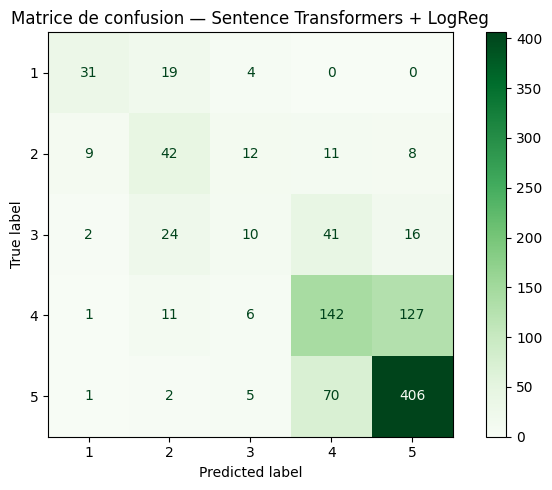

In [8]:
cm = confusion_matrix(y_valid, y_pred_valid)

plt.figure(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['1','2','3','4','5'])
disp.plot(cmap='Greens', ax=plt.gca())
plt.title('Matrice de confusion — Sentence Transformers + LogReg')
plt.tight_layout()
plt.show()

## 7. Comparaison avec la baseline TF-IDF

On compare les résultats avec ceux obtenus en Section TF-IDF.
Valeurs de référence TF-IDF :
- Logistic Regression : Accuracy = 63.9%, F1 macro = 0.516
- LinearSVC           : Accuracy = 60.4%, F1 macro = 0.489

                       Modèle  Accuracy (valid)  F1 macro (valid)
              TF-IDF + LogReg             0.639          0.516300
SentenceTransformers + LogReg             0.631          0.509722
           TF-IDF + LinearSVC             0.604          0.488700


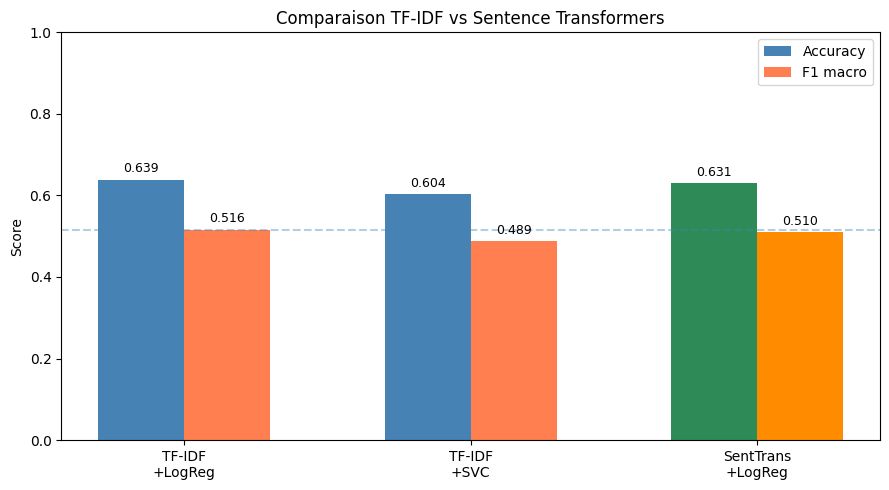

In [9]:
# ── Tableau comparatif ───────────────────────────────────────────────────────
# Résultats TF-IDF (obtenus dans le notebook précédent)
baseline_results = {
    'Modèle'          : ['TF-IDF + LogReg', 'TF-IDF + LinearSVC', 'SentenceTransformers + LogReg'],
    'Accuracy (valid)': [0.6390,            0.6040,              acc],
    'F1 macro (valid)': [0.5163,            0.4887,              f1],
}
results_df = pd.DataFrame(baseline_results).sort_values('F1 macro (valid)', ascending=False)
print(results_df.to_string(index=False))

# ── Graphique ────────────────────────────────────────────────────────────────
labels  = ['TF-IDF\n+LogReg', 'TF-IDF\n+SVC', 'SentTrans\n+LogReg']
acc_vals = [0.6390, 0.6040, acc]
f1_vals  = [0.5163, 0.4887, f1]

x = np.arange(len(labels))
w = 0.3

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - w/2, acc_vals, w, label='Accuracy',         color=['steelblue','steelblue','seagreen'])
bars2 = ax.bar(x + w/2, f1_vals,  w, label='F1 macro',         color=['coral','coral','darkorange'])

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Comparaison TF-IDF vs Sentence Transformers')
ax.legend()
ax.axhline(0.5163, color='steelblue', linestyle='--', alpha=0.4, label='Référence F1 TF-IDF')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 8. Analyse des erreurs

On examine les cas mal classés pour comprendre les limites du modèle.
On regarde aussi l'écart moyen entre note réelle et prédite.

Erreurs : 369 / 1000 (36.9%)

Répartition par écart :
ecart
1    308
2     49
3     11
4      1
Name: count, dtype: int64


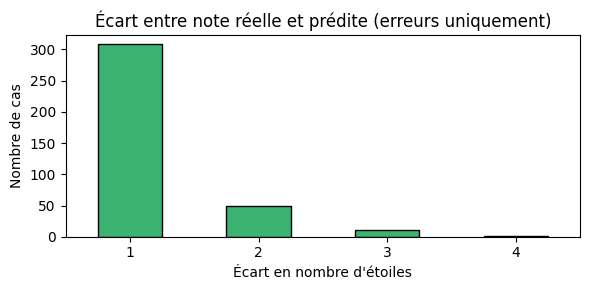

In [10]:
# ── Erreurs détaillées ───────────────────────────────────────────────────────
valid_df2 = valid_df.copy()
valid_df2['pred']    = y_pred_valid
valid_df2['correct'] = valid_df2['Rating'] == valid_df2['pred']

errors = valid_df2[~valid_df2['correct']].copy()
errors['ecart'] = (errors['Rating'] - errors['pred']).abs()

print(f'Erreurs : {len(errors)} / {len(valid_df2)} ({len(errors)/len(valid_df2)*100:.1f}%)')
print(f'\nRépartition par écart :')
print(errors['ecart'].value_counts().sort_index())

plt.figure(figsize=(6, 3))
errors['ecart'].value_counts().sort_index().plot(
    kind='bar', color='mediumseagreen', edgecolor='black'
)
plt.title("Écart entre note réelle et prédite (erreurs uniquement)")
plt.xlabel("Écart en nombre d'étoiles")
plt.ylabel('Nombre de cas')
plt.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

In [11]:
# ── Exemples mal classés ─────────────────────────────────────────────────────
# On affiche des cas intéressants : grands écarts ou notes difficiles (2★, 3★)
print('=== 5 exemples mal classés ===')
for _, row in errors.head(5).iterrows():
    print(f'\nNote réelle : {row["Rating"]}★ | Note prédite : {row["pred"]}★ | Écart : {row["ecart"]}')
    print(f'Commentaire : {str(row["Review"])[:250]}...')
    print('-' * 70)

=== 5 exemples mal classés ===

Note réelle : 3★ | Note prédite : 4★ | Écart : 1
Commentaire : interesting wife traveled years hotel ups downs certain qualities bugged most.first ups hotel staff not nicer, bar folks waiters desk, pleased attitude service around.we mainly ate buffets really n't like eating way cold food real cold hot food cold,...
----------------------------------------------------------------------

Note réelle : 4★ | Note prédite : 5★ | Écart : 1
Commentaire : animation team impressed animation team resort, special thank pablo jesus wassiel,  ...
----------------------------------------------------------------------

Note réelle : 4★ | Note prédite : 5★ | Écart : 1
Commentaire : majestic colonial great place bad thing place coffee time bring food good majestic clean junior suite standard surprise quite large, shows entertaining not shoppingthe sand beach soft, time year need care oceans rough lots fun, took day excursion sam...
---------------------------------------

## 9. Prédiction finale sur le jeu de test

On applique le modèle entraîné sur le jeu de test et on évalue les performances finales.
Les prédictions sont sauvegardées dans un CSV.

In [12]:
y_pred_test = clf.predict(X_test)

# Évaluation sur test
acc_test = accuracy_score(y_test, y_pred_test)
f1_test  = f1_score(y_test, y_pred_test, average='macro')

print(f'=== Sentence Transformers + LogReg — Résultats sur TEST ===')
print(f'Accuracy         : {acc_test:.4f} ({acc_test*100:.2f}%)')
print(f'F1-score (macro) : {f1_test:.4f}')
print(classification_report(
    y_test, y_pred_test,
    target_names=['1 etoile','2 etoiles','3 etoiles','4 etoiles','5 etoiles']
))

# Sauvegarde des prédictions
pd.DataFrame({
    'Review'        : test_df['Review'],
    'Rating_reel'   : test_df['Rating'],
    'Rating_predit' : y_pred_test
}).to_csv('predictions_sentence_transformers.csv', index=False)

print('\nPrédictions sauvegardées dans predictions_sentence_transformers.csv')

=== Sentence Transformers + LogReg — Résultats sur TEST ===
Accuracy         : 0.6350 (63.50%)
F1-score (macro) : 0.5663
              precision    recall  f1-score   support

    1 etoile       0.67      0.67      0.67        57
   2 etoiles       0.51      0.53      0.52        81
   3 etoiles       0.53      0.28      0.37       109
   4 etoiles       0.51      0.50      0.51       287
   5 etoiles       0.73      0.82      0.77       466

    accuracy                           0.64      1000
   macro avg       0.59      0.56      0.57      1000
weighted avg       0.62      0.64      0.62      1000


Prédictions sauvegardées dans predictions_sentence_transformers.csv


## 10. Résumé final

In [ ]:
print('=' * 55)
print('RÉSUMÉ — Sentence Transformers + LogReg')
print('=' * 55)
print(f'Modèle embeddings  : all-MiniLM-L6-v2 (384 dim)')
print(f'Classifieur        : Logistic Regression (C=5.0)')
print()
print(f'Valid — Accuracy   : {acc:.4f} ({acc*100:.2f}%)')
print(f'Valid — F1 macro   : {f1:.4f}')
print(f'Test  — Accuracy   : {acc_test:.4f} ({acc_test*100:.2f}%)')
print(f'Test  — F1 macro   : {f1_test:.4f}')
print()
print(f'--- Comparaison ---')
print(f'TF-IDF + LogReg    : Acc=63.9%  F1=0.516')
print(f'SentTrans + LogReg : Acc={acc*100:.1f}%  F1={f1:.3f}')
delta_f1 = f1 - 0.516
print(f'Gain F1            : {delta_f1:+.3f}')
print()
print('Prochaine étape : Fine-tuning BERT.')
print('=' * 55)

RÉSUMÉ — Sentence Transformers + LogReg
Modèle embeddings  : all-MiniLM-L6-v2 (384 dim)
Classifieur        : Logistic Regression (C=5.0)

Valid — Accuracy   : 0.6310 (63.10%)
Valid — F1 macro   : 0.5097
Test  — Accuracy   : 0.6350 (63.50%)
Test  — F1 macro   : 0.5663

--- Comparaison ---
TF-IDF + LogReg    : Acc=63.9%  F1=0.516
SentTrans + LogReg : Acc=63.1%  F1=0.510
Gain F1            : -0.006

Prochaine étape : Fine-tuning BERT (objectif final).
